Shape: (1000, 4)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Start_Node                  1000 non-null   object 
 1   End_Node                    1000 non-null   object 
 2   Road_Distance               1000 non-null   float64
 3   Euclidean_Distance_to_Goal  1000 non-null   float64
dtypes: float64(2), object(2)
memory usage: 31.4+ KB
None

Data Types:
Start_Node                     object
End_Node                       object
Road_Distance                 float64
Euclidean_Distance_to_Goal    float64
dtype: object

Missing Values:
Start_Node                    0
End_Node                      0
Road_Distance                 0
Euclidean_Distance_to_Goal    0
dtype: int64

Statistical Summary:
       Road_Distance  Euclidean_Distance_to_Goal
count    1000.000000                 1000.000000
mean       56.

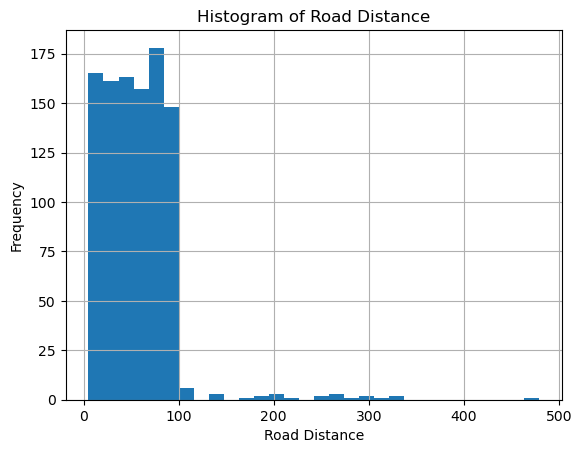

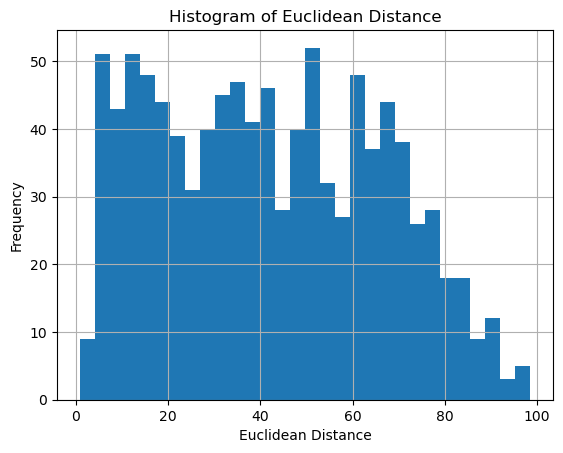

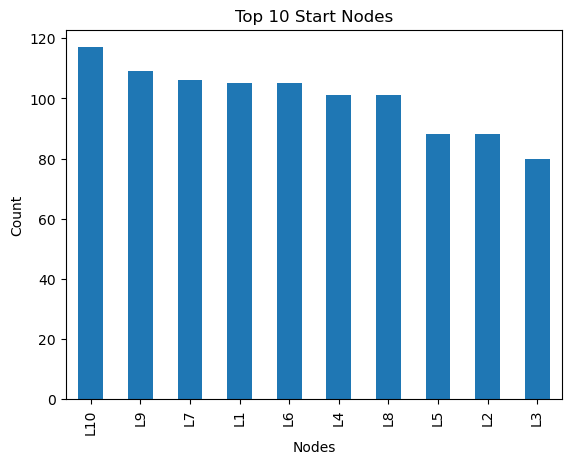

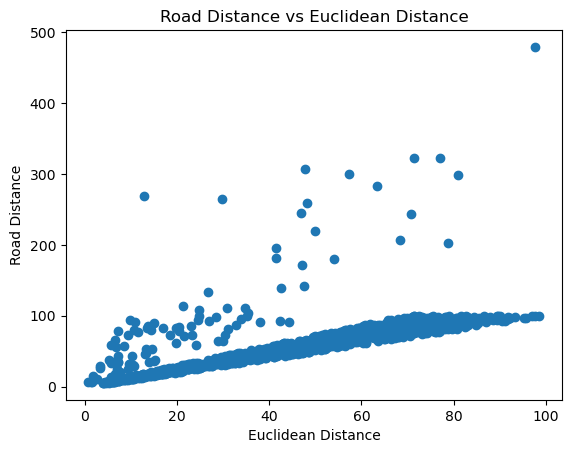

Correlation Matrix:

                            Road_Distance  Euclidean_Distance_to_Goal
Road_Distance                    1.000000                    0.652201
Euclidean_Distance_to_Goal       0.652201                    1.000000


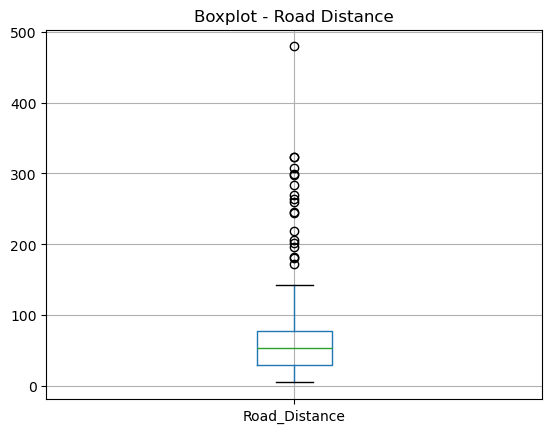

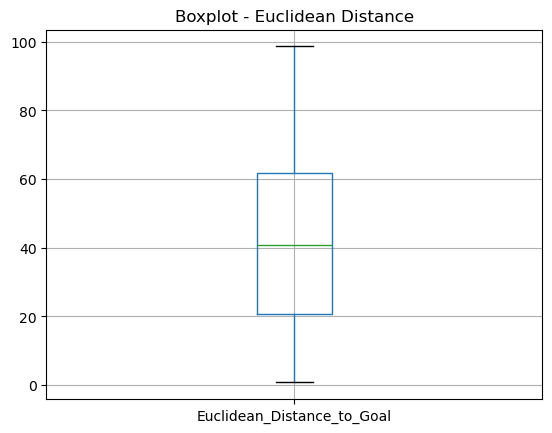


Average Road Distance per Start Node:
 Start_Node
L1     56.572952
L10    54.630684
L2     58.735341
L3     56.738750
L4     59.227228
L5     57.695909
L6     59.510095
L7     56.402264
L8     55.839703
L9     54.859083
Name: Road_Distance, dtype: float64

Top 5 Longest Routes:
     Start_Node End_Node  Road_Distance  Euclidean_Distance_to_Goal
245         L3       L5         479.38                       97.70
535        L10       L6         322.86                       71.46
586        L10       L3         322.63                       77.07
215         L4       L8         307.14                       47.68
572         L4       L2         299.50                       57.36

Start Node Frequency:
 Start_Node
L10    117
L9     109
L7     106
L1     105
L6     105
L4     101
L8     101
L5      88
L2      88
L3      80
Name: count, dtype: int64

End Node Frequency:
 End_Node
L7     109
L3     109
L8     106
L2     104
L9     101
L5     100
L1      97
L4      93
L10     93
L6      88
Name:

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("logistics_route_dataset-1.csv")

print("Shape:", df.shape)
print("\nInfo:")
print(df.info())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# Handle missing values (correct way)
df['Road_Distance'] = df['Road_Distance'].fillna(df['Road_Distance'].mean())
df['Euclidean_Distance_to_Goal'] = df['Euclidean_Distance_to_Goal'].fillna(df['Euclidean_Distance_to_Goal'].mean())

df['Start_Node'] = df['Start_Node'].fillna(df['Start_Node'].mode()[0])
df['End_Node'] = df['End_Node'].fillna(df['End_Node'].mode()[0])

# Remove duplicates
df = df.drop_duplicates()

# Final check
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

# Select numerical columns
num_cols = ['Road_Distance', 'Euclidean_Distance_to_Goal']

# Calculate statistics
print("📊 Statistical Analysis:\n")

for col in num_cols:
    print(f"--- {col} ---")
    print("Mean:", df[col].mean())
    print("Median:", df[col].median())
    print("Mode:", df[col].mode()[0])
    print("Min:", df[col].min())
    print("Max:", df[col].max())
    print("Standard Deviation:", df[col].std())
    print()


    # -------------------------------
#  1. Histograms
# -------------------------------
df['Road_Distance'].hist(bins=30)
plt.title("Histogram of Road Distance")
plt.xlabel("Road Distance")
plt.ylabel("Frequency")
plt.show()

df['Euclidean_Distance_to_Goal'].hist(bins=30)
plt.title("Histogram of Euclidean Distance")
plt.xlabel("Euclidean Distance")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
#  2. Bar Chart (Top Nodes)
# -------------------------------
df['Start_Node'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Start Nodes")
plt.xlabel("Nodes")
plt.ylabel("Count")
plt.show()

# -------------------------------
#  3. Scatter Plot
# -------------------------------
plt.scatter(df['Euclidean_Distance_to_Goal'], df['Road_Distance'])
plt.title("Road Distance vs Euclidean Distance")
plt.xlabel("Euclidean Distance")
plt.ylabel("Road Distance")
plt.show()

# -------------------------------
#  4. Correlation Analysis
# -------------------------------
correlation = df[['Road_Distance', 'Euclidean_Distance_to_Goal']].corr()

print("Correlation Matrix:\n")
print(correlation)

# -------------------------------
#  5. Boxplot (Outlier Detection)
# -------------------------------
df.boxplot(column=['Road_Distance'])
plt.title("Boxplot - Road Distance")
plt.show()

df.boxplot(column=['Euclidean_Distance_to_Goal'])
plt.title("Boxplot - Euclidean Distance")
plt.show()

# -------------------------------
# Group Analysis (Average Distance per Node)
# -------------------------------
group_data = df.groupby('Start_Node')['Road_Distance'].mean()
print("\nAverage Road Distance per Start Node:\n", group_data)

# -------------------------------
#  Top Longest Routes
# -------------------------------
top_routes = df.sort_values(by='Road_Distance', ascending=False).head(5)
print("\nTop 5 Longest Routes:\n", top_routes)

# -------------------------------
#  Value Counts (Node Frequency)
# -------------------------------
print("\nStart Node Frequency:\n", df['Start_Node'].value_counts())
print("\nEnd Node Frequency:\n", df['End_Node'].value_counts())